In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
from treeple.experimental import StreamDecisionForest
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import xgboost as xgb

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [3]:
def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_initial = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


In [6]:
def train_model(X, Y, model=None, sample_weight = None):
    """Train or continue training the XGBRegressor."""
    if model is None:
        model = MLPRegressor(hidden_layer_sizes=(128,128), activation='relu', solver='adam',
                             alpha=0.0001, batch_size=32, learning_rate='adaptive', learning_rate_init=0.01,
                             max_iter=2000, shuffle=True, random_state=None, tol=0.00001,early_stopping=False,validation_fraction = 0.1)
        if sample_weight is None:
            model.fit(X, Y)
        else:
            model.fit(X, Y,sample_weight = sample_weight)
    else:
        if sample_weight is None:
            # model = MLPRegressor(hidden_layer_sizes=(128,128), activation='relu', solver='adam',
            #                  alpha=0.0001, batch_size=32, learning_rate='adaptive', learning_rate_init=0.001,
            #                  max_iter=3000, shuffle=True, random_state=None, tol=0.00001,early_stopping=False,validation_fraction = 0.1)
            # model.fit(X,Y)
            model.partial_fit(X,Y)
        else:
            model.partial_fit(X,Y)
    return model

def predict_paths(model, df_paths, t_start, t_prime):
    n_paths = df_paths.shape[0]
    preds = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        # if df_paths.shape[1] == 1:
        #     cand_pe = position_encoder(df_paths, type="onehot")
        # else:
        cand_pe = position_encoder(df_paths.iloc[:,i], type="onehot")
        curr_time = t_start + 1 + i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0]) * curr_time, tdim=50)
        features = np.hstack([cand_pe, time_emb])
        preds[:, i] = model.predict(features)
    return preds

def choose_next_state(rf_action, rf_value, current_state, t_now, t_prime_action, t_prime_value, gamma):
    """Pick best next state based on discounted rewards."""
    df_paths = enumerate_paths(x0=current_state, t_initial=t_now, t_prime=t_prime_action)
    df_paths_value = df_paths.iloc[:,[-1]]
    # print(df_paths,df_paths_value)
    preds_action = predict_paths(rf_action, df_paths, t_now, t_prime_action)
    preds_value = predict_paths(rf_value, df_paths_value, t_now+t_prime_action ,t_prime_value)
    rewards_matrix = preds_action[:, 1:]
    # print(preds_value.shape)
    rewards_matrix = np.hstack([rewards_matrix,preds_value])
    discounts = gamma ** np.arange(0, t_prime_action+1) # Make t_prime_value = 1
    total_disc = (rewards_matrix * discounts).sum(axis=1)
    
    best_idx = np.argmax(total_disc)
    return df_paths.iloc[best_idx, 1], df_paths, rewards_matrix

def run_inference(rf_action, rf_value, start_state, T_p, t_prime_action, t_prime_value, gamma, rewards_in_period):
    """Generate future trajectory and compute regret."""
    current_state = start_state
    future_states = [current_state]

    for delta_t in range(100):
        next_state, df_paths, preds = choose_next_state(rf_action, rf_value, current_state, T_p + delta_t, t_prime_action, t_prime_value, gamma)
        future_states.append(next_state)
        current_state = next_state

    # compute rewards
    irewards_test = [reward_simulate(future_states[i], T_p+i, rewards_in_period) 
                     for i in range(1, len(future_states))]
    preward = compute_normalized_future_rewards(irewards_test, 100, gamma,normalization=True)

    # optimal path benchmark
    path, ireward_opt = path_opt(future_states[0], T_p, 100)
    preward_opt_test = compute_normalized_future_rewards(ireward_opt[1:], 100, gamma,normalization=True)

    pregret = (np.sum(preward_opt_test).item() - np.sum(preward).item()) / 100

    # plotting
    # plt.plot(np.arange(T_p+1, T_p+101), future_states[1:], label="learned")
    # plt.plot(np.arange(T_p,   T_p+101), path, label="optimal")
    # plt.legend()
    # plt.show()

    return pregret,preds


In [13]:
T = 200
gamma = 0.9
t_prime_action = 6
t_prime_value = 0
threshold = 1e-4
DELTA_T = 800
# PREGRETS = []

for rep in range(3,6):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=6000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards
    # is_pos = (Y_train_value > threshold).astype(int)
    # pos = is_pos.sum()
    # neg = len(Y_train_value) - pos
    # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
    rf_value = train_model(X_train, Y_train_value)
    print(Y_train_value.shape)
    
    PREGRET = []
    current_state = states[T,0]
    future_state = [current_state]
    for delta_t in range(1,DELTA_T+1):
        next_state, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, T+delta_t-1, t_prime_action, t_prime_value, gamma)
        next_time = T+delta_t
        next_features = np.hstack([
            position_encoder(np.array([next_state]), type="onehot"),
            time_embedding_np(next_time+1, tdim=50).reshape(1,-1)
        ])
        next_reward = reward_simulate(next_state, next_time, rewards_in_period)

        ## PolicyIteration
        # X_train = np.vstack([X_train, next_features])
        # Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])
        X_train = np.vstack([X_train, next_features])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), [[next_reward]]])

        ## Offline
        # X_train = np.hstack([position_encoder(states[:T+delta_t,0], type="onehot"), states[:T+delta_t,1:]])
        # Y_train_action = irewards[:T+delta_t]

        # rf_action = train_model(next_features, np.array([[next_reward]]).ravel())
        rf_action = train_model(X_train, Y_train_action.ravel(), None)


        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = next_time,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value.ravel())
        # rf_value = train_model(X_train, Y_train_value,None)
        
        current_state = next_state  # move forward
        future_state.append(current_state)

    
        T_p = delta_t + T
        start_state = current_state
        pregret_val,pred = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        print(f"rep {rep}, T_train {T_p}, pregret={pregret_val:.4f}")
        PREGRET.append(pregret_val)

    PREGRETS.append(PREGRET)


(200,)
rep 3, T_train 201, pregret=1.3337
rep 3, T_train 202, pregret=1.3704
rep 3, T_train 203, pregret=1.4121
rep 3, T_train 204, pregret=1.3201
rep 3, T_train 205, pregret=1.2599
rep 3, T_train 206, pregret=1.2690
rep 3, T_train 207, pregret=1.2369
rep 3, T_train 208, pregret=1.2098
rep 3, T_train 209, pregret=1.2120
rep 3, T_train 210, pregret=1.1666
rep 3, T_train 211, pregret=1.1624
rep 3, T_train 212, pregret=1.1500
rep 3, T_train 213, pregret=1.1087
rep 3, T_train 214, pregret=1.0891
rep 3, T_train 215, pregret=1.1715
rep 3, T_train 216, pregret=1.0521
rep 3, T_train 217, pregret=1.0132
rep 3, T_train 218, pregret=0.9745
rep 3, T_train 219, pregret=0.9597
rep 3, T_train 220, pregret=1.2418
rep 3, T_train 221, pregret=1.3383
rep 3, T_train 222, pregret=1.3726
rep 3, T_train 223, pregret=1.3414
rep 3, T_train 224, pregret=1.3309
rep 3, T_train 225, pregret=1.2976
rep 3, T_train 226, pregret=1.2784
rep 3, T_train 227, pregret=1.2513
rep 3, T_train 228, pregret=1.2098
rep 3, T_trai

/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_54791/1095527026.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('GnBu')


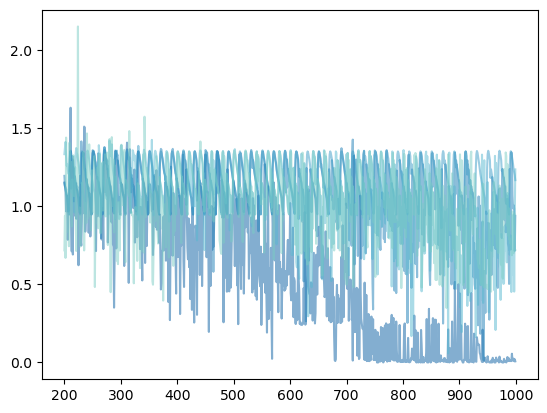

In [21]:
# plt.plot(np.arange(300,340),future_state[1:])
cmap = cm.get_cmap('GnBu')
cmap_color = [cmap(0.9 - i*0.1) for i in range(10)]
for i in range(5):
    plt.plot(np.arange(200,1000),PREGRETS[i],alpha = 0.5,color = cmap_color[i])

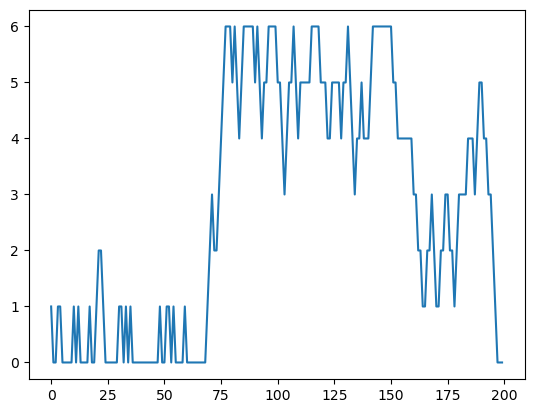

100.73521152000002


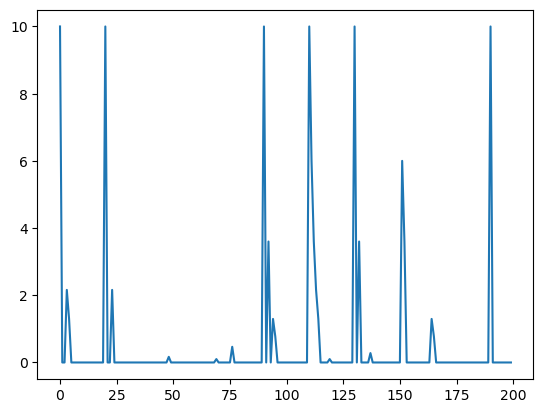

In [68]:
actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=6000,
        tdim=50, n_sessions=1, seed=515+5
    )
plt.plot(np.arange(0,200),states[:200,0])
plt.show()
plt.plot(np.arange(0,200),irewards[:200])
print(sum(irewards[:200]))

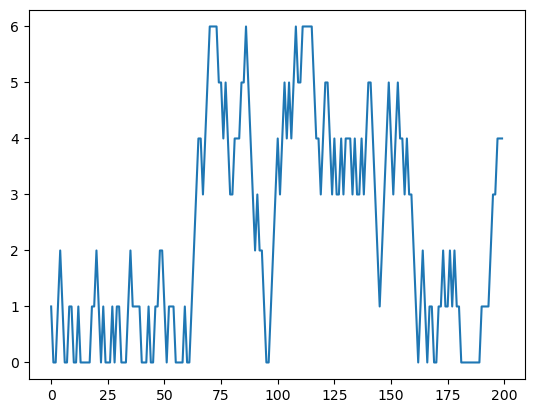

63.39674111999999


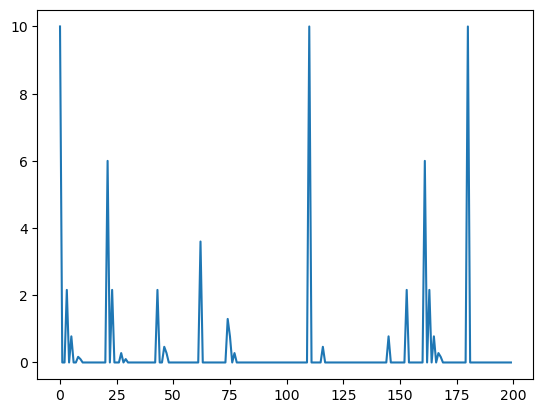

In [47]:
actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=6000,
        tdim=50, n_sessions=1, seed=515+7
    )
plt.plot(np.arange(0,200),states[:200,0])
plt.show()
plt.plot(np.arange(0,200),irewards[:200])
print(sum(irewards[:200]))

In [ ]:
T = 200
gamma = 0.9
t_prime_action = 9
t_batch = 1
t_prime_value = 0
DELTA_T = 600
PREGRETS = []
for rep in range(10):
    # one simulation per rep
    actions, states, irewards, times = simulate_data_raw(
        rewards_in_period=rewards_in_period,
        session_duration=6000,
        tdim=50, n_sessions=1, seed=515+rep
    )
    prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)

    # initial dataset
    X_train = np.hstack([position_encoder(states[:T,0], type="onehot"), states[:T,1:]])
    Y_train_action = irewards[:T]
    rf_action = train_model(X_train, Y_train_action, None)

    Y_train_value = prewards
    rf_value = train_model(X_train, Y_train_value)
    # print(Y_train_value.shape)

    PREGRET = []
    # T+=15
    current_state = states[T,0]
    future_state = [current_state]
    print(current_state)
    for delta_t in range(1,DELTA_T+1):
        t_init = T+(delta_t-1)*t_batch
        next_states, df_paths, preds = choose_next_state(rf_action,rf_value, current_state, t_init, t_prime_action, t_prime_value, gamma)
        NEXT_FEATURES = []
        NEXT_REWARD = []
        for actor_i in range(t_batch):
            next_time = t_init+actor_i+1
            next_state = next_states[actor_i]
            print(next_time,next_state)
            next_features = np.hstack([position_encoder(np.array([next_state]), type="onehot"),
                                       time_embedding_np(next_time+1, tdim=50).reshape(1,-1)])
            next_reward = reward_simulate(next_state, next_time, rewards_in_period)

            current_state = next_state
            future_state.append(current_state)

            NEXT_FEATURES.append(next_features)
            NEXT_REWARD.append(next_reward)
        # print(t_init+t_batch,future_states)
        NEXT_FEATURES_arr = np.vstack([NEXT_FEATURES])[:,0,:]
        NEXT_REWARD_arr = np.vstack([NEXT_REWARD])
        # PolicyIteration
        X_train = np.vstack([X_train, NEXT_FEATURES_arr])
        Y_train_action = np.vstack([Y_train_action.reshape(-1,1), NEXT_REWARD_arr.reshape(-1,1)])

        # rf_action = train_model(NEXT_FEATURES_arr, NEXT_REWARD_arr.reshape(-1,1),rf_action)
        rf_action = train_model(X_train,Y_train_action)
        # print(t_init, "rf_action train done")
        Y_train_value = make_weighted_target(Y_train_action, gamma ,T = t_init+t_batch,normalization = False)
        # is_pos = (Y_train_value > threshold).astype(int)
        # pos = is_pos.sum()
        # neg = len(Y_train_value) - pos
        # w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
        # print(X_train.shape,Y_train_value.shape,w.shape)
        rf_value = train_model(X_train, Y_train_value)
        # print(t_init,"rf_value train done")
        
        # T_p = delta_t + T
        # start_state = current_state
        # preward_val = run_inference(rf_action, rf_value, start_state, T_p,  t_prime_action, t_prime_value, gamma, rewards_in_period)
        # print(f"rep {rep}, T_train {T_p}, pregret={preward_val:.4f}")
        # PREGRET.append(preward_val)
        
    
    



4.0


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_54306/1214898731.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_state = next_states[actor_i]
/opt/anaconda3/envs/prolearn2/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


201 5.0


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_54306/1214898731.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_state = next_states[actor_i]
/opt/anaconda3/envs/prolearn2/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


202 5.0


...

208 5.0


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_54306/1214898731.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_state = next_states[actor_i]
/opt/anaconda3/envs/prolearn2/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


209 5.0


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_54306/1214898731.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  next_state = next_states[actor_i]
/opt/anaconda3/envs/prolearn2/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


210 5.0


In [11]:
PREGRETS_arr = np.vstack(PREGRETS)

In [12]:
PREGRETS_arr

array([[1.15188317, 1.13011664, 1.11455781, ..., 0.00862705, 0.02052444,
        0.00728905],
       [1.19468407, 1.13066575, 1.10872177, ..., 0.98467851, 0.71458936,
        0.93877078],
       [1.14702484, 1.12788949, 1.11154777, ..., 1.21858113, 1.19875115,
        1.16755235]], shape=(3, 800))